# Seizure Detection: Model Comparison

This notebook trains several classifiers on the sensor data and compares their performance using **leave-one-episode-out cross-validation** (not a random split), since a random split would leak near-identical adjacent rows between train and test.

Metrics reported per model: accuracy, precision, recall, F1, and PR-AUC. Accuracy alone is misleading here (96%+ is trivial by predicting 'normal' every time), so it's shown alongside the imbalance-aware metrics.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, auc, confusion_matrix
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - skipping XGBoost. Install with: pip install xgboost")

RANDOM_STATE = 42
pd.set_option("display.precision", 3)

xgboost not installed - skipping XGBoost. Install with: pip install xgboost


## 1. Load data and engineer features

Same feature engineering as the EDA notebook: compute `accel_mag`/`gyro_mag`, then keep only features with real signal (drop the constant `temperature`, the zero-correlation `humidity`, and the raw x/y/z axes once magnitudes exist).

In [11]:
df = pd.read_csv("Sample_synthetic_seizure_data.csv")
df["created_at"] = pd.to_datetime(df["created_at"])
df = df.sort_values("created_at").reset_index(drop=True)

df["accel_mag"] = np.sqrt(df.accel_x**2 + df.accel_y**2 + df.accel_z**2)
df["gyro_mag"]  = np.sqrt(df.gyro_x**2  + df.gyro_y**2  + df.gyro_z**2)

BASE_FEATURES = ["heart_rate", "spo2", "accel_mag", "gyro_mag", "ir_value", "red_value"]

print("Shape:", df.shape)
df[BASE_FEATURES + ["seizure"]].head()

Shape: (3000, 18)


,heart_rate,spo2,accel_mag,gyro_mag,ir_value,red_value,seizure
0,73.3,97.9,0.432,2.159,2742,981,0
1,77.3,98.1,0.432,2.166,2644,934,0
2,78.4,97.9,0.418,1.135,2535,961,0
3,77.3,97.4,0.419,3.027,2817,933,0
4,70.9,97.6,0.434,2.107,2791,959,0


## 2. Add rolling-window features

Seizure episodes last 30-40 seconds, so a 5-second rolling window gives each row local temporal context instead of judging isolated instants.

In [12]:
WINDOW = 5  # seconds, data is sampled at 1 Hz

def add_rolling_features(data, cols, window):
    data = data.copy()
    for col in cols:
        roll = data[col].rolling(window, min_periods=1)
        data[f"{col}_roll_mean"] = roll.mean()
        data[f"{col}_roll_std"] = roll.std().fillna(0)
        data[f"{col}_roll_max"] = roll.max()
        data[f"{col}_rate"] = data[col].diff().fillna(0)
    return data

df = add_rolling_features(df, BASE_FEATURES, WINDOW)

FEATURE_COLS = BASE_FEATURES.copy()
for col in BASE_FEATURES:
    FEATURE_COLS += [f"{col}_roll_mean", f"{col}_roll_std", f"{col}_roll_max", f"{col}_rate"]

print(f"{len(FEATURE_COLS)} features:")
FEATURE_COLS

30 features:


['heart_rate',
 'spo2',
 'accel_mag',
 'gyro_mag',
 'ir_value',
 'red_value',
 'heart_rate_roll_mean',
 'heart_rate_roll_std',
 'heart_rate_roll_max',
 'heart_rate_rate',
 'spo2_roll_mean',
 'spo2_roll_std',
 'spo2_roll_max',
 'spo2_rate',
 'accel_mag_roll_mean',
 'accel_mag_roll_std',
 'accel_mag_roll_max',
 'accel_mag_rate',
 'gyro_mag_roll_mean',
 'gyro_mag_roll_std',
 'gyro_mag_roll_max',
 'gyro_mag_rate',
 'ir_value_roll_mean',
 'ir_value_roll_std',
 'ir_value_roll_max',
 'ir_value_rate',
 'red_value_roll_mean',
 'red_value_roll_std',
 'red_value_roll_max',
 'red_value_rate']

## 3. Identify seizure episodes for leave-one-episode-out CV

Rows are grouped by which seizure episode they belong to (or are nearest to), so each cross-validation fold holds out one *entire* episode rather than randomly-shuffled rows.

In [13]:
seizure_indices = df.index[df["seizure"] == 1]
groups = seizure_indices.to_series().diff().ne(1).cumsum()

episode_bounds = []
for eid, group in seizure_indices.to_series().groupby(groups):
    start_idx, end_idx = group.iloc[0], group.iloc[-1]
    episode_bounds.append((start_idx, end_idx))

midpoints = [(s + e) // 2 for s, e in episode_bounds]
df["episode_fold"] = df.index.map(lambda i: int(np.argmin([abs(i - m) for m in midpoints])))

n_episodes = len(episode_bounds)
print(f"Found {n_episodes} seizure episodes -> {n_episodes}-fold leave-one-episode-out CV")
df["episode_fold"].value_counts().sort_index()

Found 3 seizure episodes -> 3-fold leave-one-episode-out CV


episode_fold
0    1093
1     866
2    1041
Name: count, dtype: int64

## 4. Define the models to compare

Class imbalance is handled via `class_weight='balanced'` (or `scale_pos_weight` for gradient boosting) rather than synthetic oversampling, which can create unrealistic interpolated points in time-series data.

In [14]:
def make_models(scale_pos_weight):
    models = {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=6, class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            random_state=RANDOM_STATE
        ),
        "SVM (RBF)": SVC(
            kernel="rbf", class_weight="balanced", probability=True,
            random_state=RANDOM_STATE
        ),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
            random_state=RANDOM_STATE
        )
    return models

# models that benefit from scaled features (distance/gradient based)
SCALE_SENSITIVE = {"Logistic Regression", "SVM (RBF)", "K-Nearest Neighbors"}

## 5. Run leave-one-episode-out CV for every model

In [15]:
X = df[FEATURE_COLS]
y = df["seizure"]

all_results = []

for fold in range(n_episodes):
    train_mask = df["episode_fold"] != fold
    test_mask = df["episode_fold"] == fold

    X_train_raw, y_train = X[train_mask], y[train_mask]
    X_test_raw, y_test = X[test_mask], y[test_mask]

    scaler = StandardScaler().fit(X_train_raw)
    X_train_scaled = scaler.transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    n_pos, n_neg = y_train.sum(), (y_train == 0).sum()
    scale_pos_weight = n_neg / max(n_pos, 1)

    models = make_models(scale_pos_weight)

    for name, model in models.items():
        if name in SCALE_SENSITIVE:
            X_train, X_test = X_train_scaled, X_test_scaled
        else:
            X_train, X_test = X_train_raw, X_test_raw

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred.astype(float)

        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_curve, precision_curve)

        episode_rows = (y_test == 1)
        detected = bool((y_pred[episode_rows.values] == 1).any()) if episode_rows.any() else None

        all_results.append({
            "fold": fold,
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "pr_auc": pr_auc,
            "episode_detected": detected,
        })

results_df = pd.DataFrame(all_results)
results_df

/Users/sarathvenkat/Documents/Seizure_risk_project/backend/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/sarathvenkat/Documents/Seizure_risk_project/backend/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/sarathvenkat/Documents/Seizure_risk_project/backend/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,fold,model,accuracy,precision,recall,f1,pr_auc,episode_detected
0,0,Logistic Regression,1.000,1.000,1.000,1.000,1.000,True
1,0,Random Forest,1.000,1.000,1.000,1.000,1.000,True
2,0,Gradient Boosting,1.000,1.000,1.000,1.000,1.000,True
3,0,SVM (RBF),0.999,0.969,1.000,0.984,1.000,True
4,0,K-Nearest Neighbors,0.999,0.969,1.000,0.984,0.999,True
5,1,Logistic Regression,0.999,0.976,1.000,0.988,1.000,True
6,1,Random Forest,1.000,1.000,1.000,1.000,1.000,True
7,1,Gradient Boosting,1.000,1.000,1.000,1.000,1.000,True
8,1,SVM (RBF),0.997,0.932,1.000,0.965,1.000,True
9,1,K-Nearest Neighbors,0.998,0.976,0.976,0.976,0.999,True


## 6. Summary: average performance per model across all held-out episodes

This is the number that matters most given only 3 episodes exist: how many of the 3 held-out episodes did each model actually detect, plus its average row-level metrics.

In [16]:
summary = results_df.groupby("model").agg(
    mean_accuracy=("accuracy", "mean"),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_f1=("f1", "mean"),
    mean_pr_auc=("pr_auc", "mean"),
    episodes_detected=("episode_detected", "sum"),
).sort_values("mean_pr_auc", ascending=False)

summary["episodes_detected"] = summary["episodes_detected"].astype(int).astype(str) + f" / {n_episodes}"
summary

,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_pr_auc,episodes_detected
model,,,,,,
Gradient Boosting,1.000,1.000,1.000,1.000,1.000,3 / 3
Logistic Regression,1.000,0.992,1.000,0.996,1.000,3 / 3
Random Forest,1.000,1.000,1.000,1.000,1.000,3 / 3
SVM (RBF),0.998,0.941,1.000,0.970,1.000,3 / 3
K-Nearest Neighbors,0.999,0.981,0.992,0.987,0.999,3 / 3


## 7. Visualize model comparison

Accuracy is included for reference, but PR-AUC and recall are the metrics that actually reflect performance on the rare seizure class.

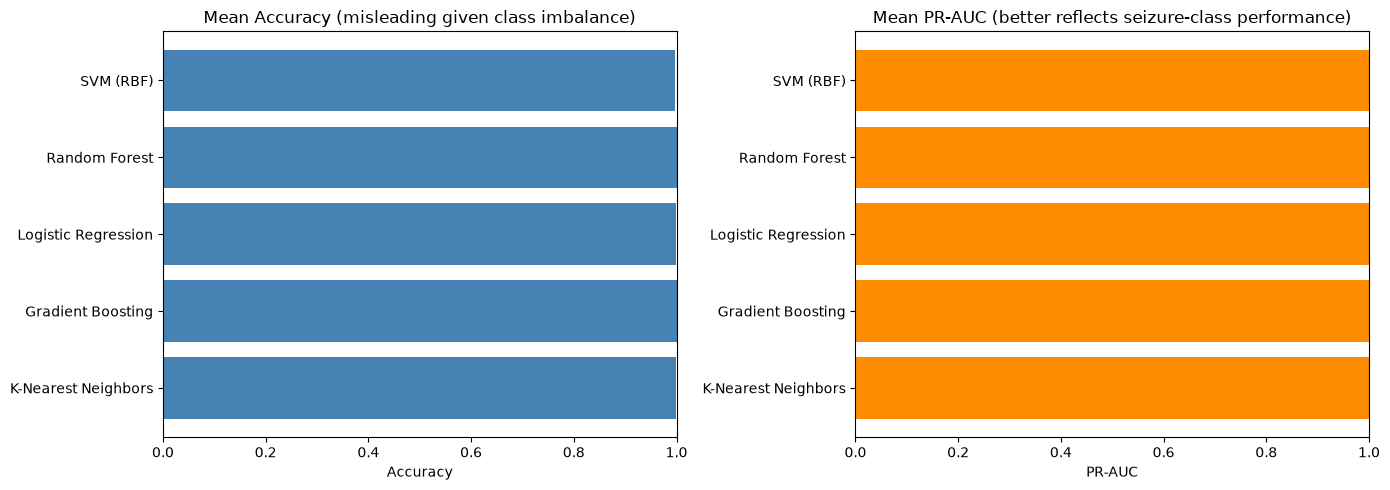

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_sorted = summary.sort_values("mean_pr_auc")

axes[0].barh(summary_sorted.index, summary_sorted["mean_accuracy"], color="steelblue")
axes[0].set_title("Mean Accuracy (misleading given class imbalance)")
axes[0].set_xlabel("Accuracy")
axes[0].set_xlim(0, 1)

axes[1].barh(summary_sorted.index, summary_sorted["mean_pr_auc"], color="darkorange")
axes[1].set_title("Mean PR-AUC (better reflects seizure-class performance)")
axes[1].set_xlabel("PR-AUC")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 8. Per-fold breakdown (does performance hold across all 3 episodes?)

With only 3 episodes, a model that does well on 2 folds and badly on the third is more informative than the average alone. Check for this before trusting the summary table above.

In [18]:
pivot = results_df.pivot(index="model", columns="fold", values="pr_auc")
pivot.columns = [f"Episode {c} held out" for c in pivot.columns]
pivot.style.background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)

,Episode 0 held out,Episode 1 held out,Episode 2 held out
model,,,
Gradient Boosting,1.000000,1.000000,1.000000
K-Nearest Neighbors,0.998976,0.998810,1.000000
Logistic Regression,1.000000,1.000000,1.000000
Random Forest,1.000000,1.000000,1.000000
SVM (RBF),1.000000,1.000000,1.000000


## Notes

- **Accuracy is shown for completeness but shouldn't drive model choice** here - with ~96% of rows being 'normal', a model that predicts 'normal' for everything still scores ~96% accuracy while catching zero seizures.
- **PR-AUC, recall, and `episodes_detected`** are the metrics worth prioritizing: they reflect whether the model actually catches the rare, important class.
- With only 3 seizure episodes total, treat these results as a preliminary comparison, not a validated benchmark - the real test is performance on new, unseen episodes.

In [20]:
# ============================================================
# FINAL MODEL TRAINING + SAVE
# ============================================================

import os
import pickle
from sklearn.ensemble import GradientBoostingClassifier


print("==============================================")
print("       FINAL SEIZURE MODEL TRAINING")
print("==============================================")


# ------------------------------------------------------------
# 1. Prepare the complete training dataset
# ------------------------------------------------------------

X_final = df[FEATURE_COLS].copy()
y_final = df["seizure"].copy()

print(f"Training samples : {len(X_final)}")
print(f"Features         : {len(FEATURE_COLS)}")
print(f"Positive samples : {(y_final == 1).sum()}")
print(f"Negative samples : {(y_final == 0).sum()}")


# ------------------------------------------------------------
# 2. Check for missing values
# ------------------------------------------------------------

if X_final.isnull().any().any():
    raise ValueError("Training data contains NaN values.")


# ------------------------------------------------------------
# 3. Check that all features are numeric
# ------------------------------------------------------------

non_numeric_columns = X_final.select_dtypes(
    exclude="number"
).columns.tolist()

if non_numeric_columns:
    raise ValueError(
        f"Non-numeric features found: {non_numeric_columns}"
    )

print()
print("Training data check: OK")


# ------------------------------------------------------------
# 4. Create the final Gradient Boosting model
# ------------------------------------------------------------

final_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# 5. Train on the FULL dataset
# ------------------------------------------------------------

print()
print("Training final Gradient Boosting model...")

final_model.fit(
    X_final,
    y_final
)

print("Training completed.")


# ------------------------------------------------------------
# 6. Create models directory
# ------------------------------------------------------------

MODEL_DIR = "models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 7. Store model + metadata
# ------------------------------------------------------------

model_artifact = {
    "model": final_model,
    "feature_cols": FEATURE_COLS,
    "window": WINDOW,
    "model_name": "Gradient Boosting",
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
}


# ------------------------------------------------------------
# 8. Save model as PKL
# ------------------------------------------------------------

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "seizure_model.pkl"
)

with open(
    MODEL_PATH,
    "wb"
) as file:

    pickle.dump(
        model_artifact,
        file
    )


# ------------------------------------------------------------
# 9. Verify saved model
# ------------------------------------------------------------

print()
print("==============================================")
print("             MODEL SAVED")
print("==============================================")

print(f"Path           : {MODEL_PATH}")
print(
    f"Features saved : "
    f"{len(model_artifact['feature_cols'])}"
)
print(
    f"Window saved   : "
    f"{model_artifact['window']}"
)
print(
    f"Model          : "
    f"{model_artifact['model_name']}"
)

print("==============================================")


# ------------------------------------------------------------
# 10. Load the PKL again to verify it
# ------------------------------------------------------------

with open(
    MODEL_PATH,
    "rb"
) as file:

    loaded_artifact = pickle.load(file)


loaded_model = loaded_artifact["model"]


# ------------------------------------------------------------
# 11. Test prediction
# ------------------------------------------------------------

test_prediction = loaded_model.predict(
    X_final.iloc[:1]
)

test_probability = loaded_model.predict_proba(
    X_final.iloc[:1]
)[0][1]


print()
print("PKL verification successful.")

print(
    f"Test prediction : "
    f"{test_prediction[0]}"
)

print(
    f"Test probability: "
    f"{test_probability:.4f}"
)

print()
print("==============================================")
print("        SEIZURE MODEL READY FOR USE")
print("==============================================")

       FINAL SEIZURE MODEL TRAINING
Training samples : 3000
Features         : 30
Positive samples : 108
Negative samples : 2892

Training data check: OK

Training final Gradient Boosting model...
Training completed.

             MODEL SAVED
Path           : models/seizure_model.pkl
Features saved : 30
Window saved   : 5
Model          : Gradient Boosting

PKL verification successful.
Test prediction : 0
Test probability: 0.0000

        SEIZURE MODEL READY FOR USE
